# N2 — Voucher Market Structure

**Goal.** Characterize the 10 VEV vouchers across 3 historical days. Outputs:
1. Per-strike data quality (two-sidedness, spread, depth)
2. ATM strike identification and switching behavior
3. Wall mid (deepest-tier midpoint) vs best-bid/ask mid
4. Strike triage (primary scalp / secondary / drop)
5. Hedge feasibility under the VEV-200 cap
6. Realized trade activity per strike

**Conventions.** Vocabulary defined inline at first use:
- *mid*: midpoint of best-bid and best-ask quotes
- *wall mid* (FH convention): midpoint of the deepest-size visible quote on each side; the largest order at any of the 3 quoted levels is taken as the "wall"
- *delta* ($\Delta$): $\partial C / \partial S$ for a Black-Scholes call, $\Delta = N(d_1)$
- *vega* ($\nu$): $\partial C / \partial \sigma = S\,\phi(d_1)\sqrt{T}$
- *moneyness*: $m = \log(K/S)/\sqrt{T}$ (FH form, used in N3/N4)
- *ATM* / *ITM* / *OTM*: at-, in-, out-of-the-money; for a call, ITM = $S > K$, OTM = $S < K$

Position limits: 200 for the underlying VEV, 300 per voucher strike.

TTE schedule (per CLAUDE.md): historical day 0 / 1 / 2 → TTE 8 / 7 / 6 days. Live R3 simulation begins at TTE = 5d. Where a single number is needed below we use TTE = 5d (the relevant value for trader v1).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

DATA_DIR = "../r3_datacap"
CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

VOUCHERS = ["VEV_4000","VEV_4500","VEV_5000","VEV_5100","VEV_5200",
            "VEV_5300","VEV_5400","VEV_5500","VEV_6000","VEV_6500"]
STRIKES = {v: int(v.split("_")[1]) for v in VOUCHERS}
STRIKE_LIST = sorted(STRIKES.values())
LIMIT_VOUCHER = 300
LIMIT_VEV = 200
DAYS_PER_YEAR = 365

pd.set_option("display.float_format", lambda x: f"{x:.4f}" if abs(x) < 1e6 else f"{x:.2e}")

## 1. Load and concatenate price data

Three days of 100µs-spaced ticks (timestamps 0 → 999 900 in steps of 100), so 10 000 ticks/day × 12 products = 120 000 rows per file. We add `global_ts = day*1e6 + timestamp` so plots are continuous across day boundaries.

In [2]:
frames = []
for d in [0, 1, 2]:
    df = pd.read_csv(f"{DATA_DIR}/prices_round_3_day_{d}.csv", sep=";")
    frames.append(df)
prices = pd.concat(frames, ignore_index=True)
prices["global_ts"] = prices["day"] * 1_000_000 + prices["timestamp"]

print("Rows per day:")
print(prices.groupby("day").size())
print("\nProducts:", sorted(prices["product"].unique()))
print("\nTimestamp grid: step =", np.diff(prices[prices["product"]=="VELVETFRUIT_EXTRACT"]["timestamp"].values[:5]))

Rows per day:
day
0    120000
1    120000
2    120000
dtype: int64

Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']

Timestamp grid: step = [100 100 100 100]


## 2. Per-strike data quality

For each strike compute: % of ticks with a two-sided market, bid-ask spread quantiles (P25/P50/P75), median top-of-book depth (sum of best-bid and best-ask volumes), and median total visible depth across all 3 levels.

Trading interpretation: high `pct_two_sided` means we can always quote against a real market; small `spread_med` means cheap round-trips for any scalping signal; large `top_depth_med` means our orders aren't likely to clear the book.

In [3]:
records = []
for v in VOUCHERS:
    sub = prices[prices["product"] == v].copy()
    n = len(sub)
    has_bid = sub["bid_price_1"].notna()
    has_ask = sub["ask_price_1"].notna()
    two_sided = has_bid & has_ask
    spread = (sub["ask_price_1"] - sub["bid_price_1"]).where(two_sided)
    top_depth = (sub["bid_volume_1"] + sub["ask_volume_1"]).where(two_sided)
    bid_depths = sub[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].fillna(0).sum(axis=1)
    ask_depths = sub[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].fillna(0).sum(axis=1)
    total_depth = bid_depths + ask_depths
    records.append({
        "strike": STRIKES[v],
        "n_ticks": n,
        "pct_two_sided": 100 * two_sided.mean(),
        "spread_p25": spread.quantile(0.25),
        "spread_med": spread.median(),
        "spread_p75": spread.quantile(0.75),
        "top_depth_med": top_depth.median(),
        "total_depth_med": total_depth.median(),
        "mid_med": sub["mid_price"].median(),
        "mid_min": sub["mid_price"].min(),
        "mid_max": sub["mid_price"].max(),
    })
quality = pd.DataFrame(records).sort_values("strike").reset_index(drop=True)
quality.to_csv(f"{CACHE_DIR}/n2_quality.csv", index=False)
quality

,strike,n_ticks,pct_two_sided,spread_p25,spread_med,spread_p75,top_depth_med,total_depth_med,mid_med,mid_min,mid_max
0,4000,30000,100.0000,21.0000,21.0000,21.0000,22.0000,66.0000,1249.5000,1198.0000,1300.0000
1,4500,30000,100.0000,16.0000,16.0000,16.0000,18.0000,54.0000,749.0000,698.5000,799.5000
2,5000,30000,100.0000,6.0000,6.0000,6.0000,31.0000,54.0000,254.0000,206.5000,300.5000
3,5100,30000,100.0000,4.0000,4.0000,5.0000,38.0000,54.0000,166.5000,125.0000,205.5000
4,5200,30000,100.0000,3.0000,3.0000,3.0000,45.0000,54.0000,96.0000,64.0000,122.5000
5,5300,30000,100.0000,2.0000,2.0000,2.0000,40.0000,44.0000,47.0000,26.5000,65.5000
6,5400,30000,100.0000,1.0000,1.0000,2.0000,44.0000,44.0000,16.5000,6.5000,27.0000
7,5500,30000,100.0000,1.0000,1.0000,1.0000,44.0000,44.0000,6.5000,2.5000,12.5000
8,6000,30000,100.0000,1.0000,1.0000,1.0000,44.0000,44.0000,0.5000,0.5000,0.5000
9,6500,30000,100.0000,1.0000,1.0000,1.0000,30.0000,30.0000,0.5000,0.5000,0.5000


**Reading this table.** Two-sided availability is 100% on every strike — there is no liquidity-driven reason to drop any of them. Spreads narrow monotonically from 21 ticks at K=4000 (deep ITM, basically intrinsic) down to 1 tick at K=5400+. The mid range ($mid_{max} - mid_{min}$) is informative: K=6000 and K=6500 are pinned at 0.5 across all 30 000 ticks — they are at the minimum quotable price floor and behave like a constant, not an option. K=4000 and K=4500 are near intrinsic everywhere (median mid = 1249.5 and 749 vs $S \approx 5250$, so $S - K \approx 1250 / 750$). Real time value lives in the 5000–5500 range.

## 3. Mid-price time series (all 10 vouchers + VEV)

Pivot to wide format and plot all voucher mids alongside VEV across the 3 days. Vertical red dashes mark day boundaries (TTE drops by 1 day at each).

VEV mid range across 3 days: [5198.0, 5300.0]   median=5249.5   stdev=15.63
Tick count: 30000


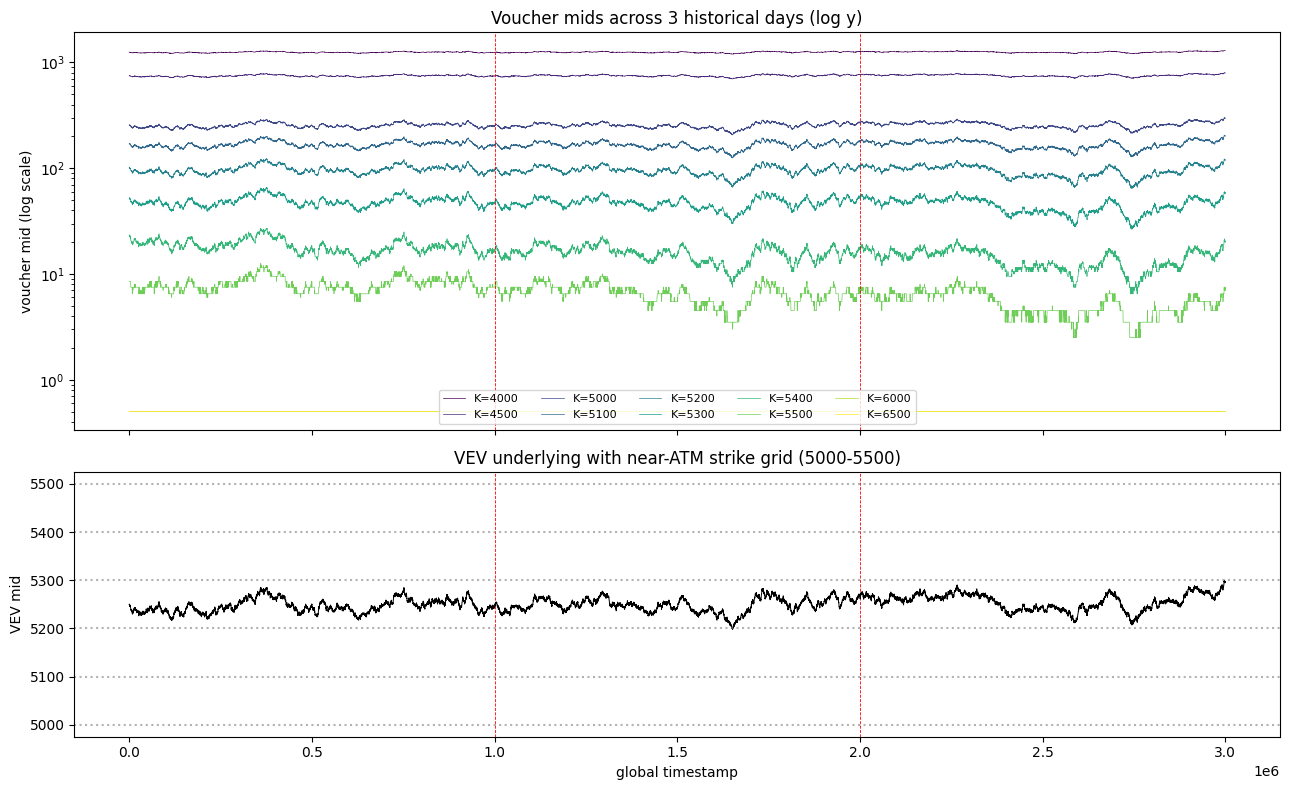

In [4]:
mids = (prices
        .pivot_table(index=["day", "timestamp", "global_ts"],
                     columns="product", values="mid_price")
        .reset_index()
        .sort_values("global_ts")
        .reset_index(drop=True))
S = mids["VELVETFRUIT_EXTRACT"].to_numpy()
print(f"VEV mid range across 3 days: [{S.min():.1f}, {S.max():.1f}]   median={np.median(S):.1f}   stdev={S.std():.2f}")
print(f"Tick count: {len(mids)}")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})
cmap = plt.cm.viridis
for i, v in enumerate(VOUCHERS):
    color = cmap(i / (len(VOUCHERS) - 1))
    axes[0].plot(mids["global_ts"], mids[v], color=color, lw=0.5, label=f"K={STRIKES[v]}")
axes[0].set_yscale("log")
axes[0].set_ylabel("voucher mid (log scale)")
axes[0].set_title("Voucher mids across 3 historical days (log y)")
axes[0].legend(ncol=5, fontsize=8, loc="lower center")
for d in [1, 2]:
    axes[0].axvline(d * 1_000_000, color="red", ls="--", lw=0.6)
    axes[1].axvline(d * 1_000_000, color="red", ls="--", lw=0.6)
axes[1].plot(mids["global_ts"], S, "k-", lw=0.7)
for k in STRIKE_LIST:
    if 5000 <= k <= 5500:
        axes[1].axhline(k, ls=":", color="grey", alpha=0.6)
axes[1].set_ylabel("VEV mid")
axes[1].set_xlabel("global timestamp")
axes[1].set_title("VEV underlying with near-ATM strike grid (5000-5500)")
fig.tight_layout()
plt.show()

**Observation.** VEV trades in a 102-point band ($\sim$ 2% of price) over 3 days. The underlying never approaches K=5000 from above or K=5500 from below — only K=5200 and K=5300 are ever truly ATM. Day boundaries don't cause visible price discontinuities in the underlying, but voucher mids do shift down at each day break (TTE decay).

## 4. Wall mid vs best-quote mid

FH used "wall mid" — the midpoint of the deepest-sized quote on each side — as their pricing anchor instead of the standard best-bid/ask mid. Their reasoning: in a tiered book where the deepest tier is the market-maker layer, that midpoint is more informative about fair value than a thin top-of-book retail quote.

Below we compute both per voucher, then quantify the per-strike disagreement.

In [5]:
def compute_wall_mids(sub):
    """Per-row: pick the bid level with the largest size and the ask level with the largest size,
    return their midpoint. NaN if either side is empty."""
    bp = sub[["bid_price_1","bid_price_2","bid_price_3"]].to_numpy()
    bv = sub[["bid_volume_1","bid_volume_2","bid_volume_3"]].to_numpy()
    ap = sub[["ask_price_1","ask_price_2","ask_price_3"]].to_numpy()
    av = sub[["ask_volume_1","ask_volume_2","ask_volume_3"]].to_numpy()
    bv_f = np.where(np.isnan(bv), -1, bv)
    av_f = np.where(np.isnan(av), -1, av)
    bidx = np.argmax(bv_f, axis=1)
    aidx = np.argmax(av_f, axis=1)
    rows = np.arange(len(sub))
    wb = bp[rows, bidx]
    wa = ap[rows, aidx]
    valid = (bv_f[rows, bidx] > 0) & (av_f[rows, aidx] > 0)
    return np.where(valid, 0.5 * (wb + wa), np.nan)

wall_records = []
wall_mid_series = {}
for v in VOUCHERS:
    sub = prices[prices["product"] == v].sort_values("global_ts").reset_index(drop=True)
    wm = compute_wall_mids(sub)
    bm = sub["mid_price"].to_numpy()
    wall_mid_series[v] = pd.Series(wm, index=sub["global_ts"].values)
    diff = wm - bm
    wall_records.append({
        "strike": STRIKES[v],
        "wall_avail_pct": 100 * (~np.isnan(wm)).mean(),
        "wall_eq_mid_pct": 100 * np.nanmean(np.abs(diff) < 1e-9),
        "abs_diff_med": np.nanmedian(np.abs(diff)),
        "abs_diff_p95": np.nanpercentile(np.abs(diff), 95),
        "abs_diff_max": np.nanmax(np.abs(diff)),
    })
wall_summary = pd.DataFrame(wall_records).sort_values("strike").reset_index(drop=True)
wall_summary.to_csv(f"{CACHE_DIR}/n2_wall_summary.csv", index=False)
wall_summary

,strike,wall_avail_pct,wall_eq_mid_pct,abs_diff_med,abs_diff_p95,abs_diff_max
0,4000,100.0000,43.5200,0.5000,0.5000,6.0000
1,4500,100.0000,76.8233,0.0000,0.5000,5.0000
2,5000,100.0000,50.7167,0.0000,0.5000,2.5000
3,5100,100.0000,52.4000,0.0000,0.5000,2.0000
4,5200,100.0000,65.3867,0.0000,0.5000,1.5000
5,5300,100.0000,73.3233,0.0000,0.5000,1.0000
6,5400,100.0000,90.3567,0.0000,0.5000,0.5000
7,5500,100.0000,96.0700,0.0000,0.0000,0.5000
8,6000,100.0000,100.0000,0.0000,0.0000,0.0000
9,6500,100.0000,100.0000,0.0000,0.0000,0.0000


**Reading this table.** `wall_eq_mid_pct` is the fraction of ticks where wall mid and standard mid coincide exactly. For strikes 5500+ the two are essentially identical (96–100%); for strikes near ATM the wall mid disagrees on roughly 30–50% of ticks but only by a single tick — the median absolute difference is 0.0 and the p95 is 0.5 across every strike. Maximum disagreement is 6.0 (one outlier on K=4000, the deep-ITM intrinsic-only strike).

**Trading implication.** On R3 data the wall_mid → mid swap is a small effect, not the structural signal it was for FH. Most ticks have a single dominant MM tier so both midpoints agree. Worth replicating in the trader as a feature flag (default = wall mid, per FH baseline) but unlikely to be the main driver of edge.

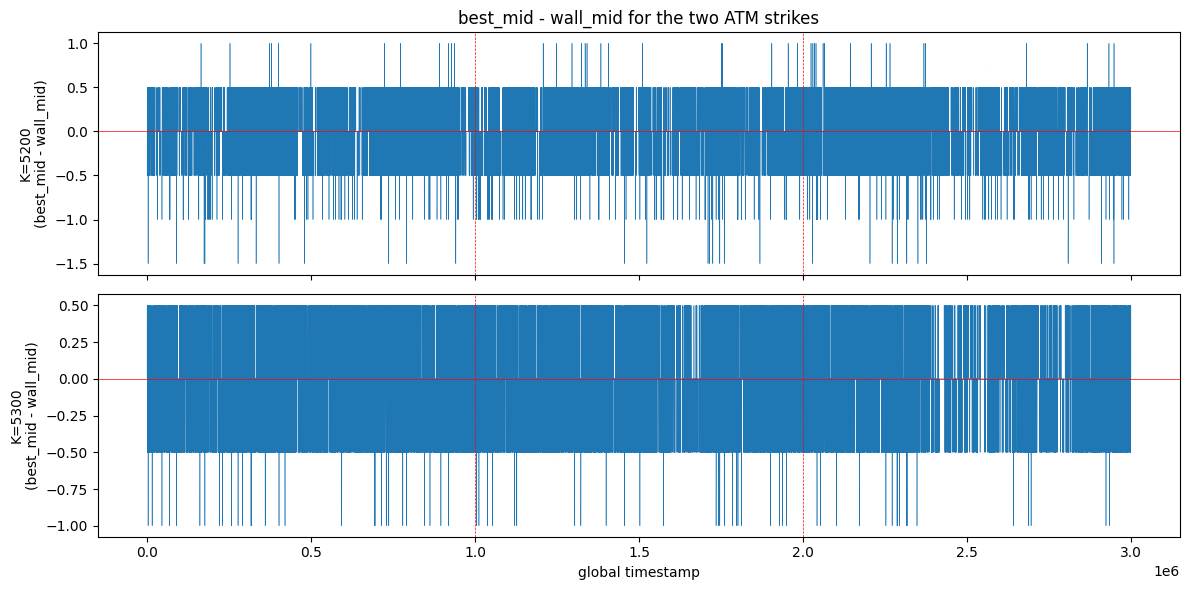

In [6]:
# Visualize wall_mid vs mid difference for the two ATM strikes (where it matters most)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, k_target in zip(axes, [5200, 5300]):
    v = f"VEV_{k_target}"
    sub = prices[prices["product"] == v].sort_values("global_ts").reset_index(drop=True)
    wm = compute_wall_mids(sub)
    bm = sub["mid_price"].to_numpy()
    ax.plot(sub["global_ts"], bm - wm, lw=0.4)
    ax.axhline(0, color="red", lw=0.5)
    ax.set_ylabel(f"K={k_target}\n(best_mid - wall_mid)")
    for d in [1, 2]:
        ax.axvline(d * 1_000_000, color="red", ls="--", lw=0.5)
axes[1].set_xlabel("global timestamp")
axes[0].set_title("best_mid - wall_mid for the two ATM strikes")
fig.tight_layout()
plt.show()

## 5. ATM strike identification

For each tick, the ATM strike is the listed strike closest to $S_t$. Track which strike holds that role over time and how often it switches. FH's strategy concentrated scalping on the current ATM and rotated when the underlying moved across a strike boundary.

ATM strike switches: 523 / 30000 ticks (1.74%)

ATM strike distribution (tick count and %):
      ticks     pct
5200  15540 51.8000
5300  14460 48.2000


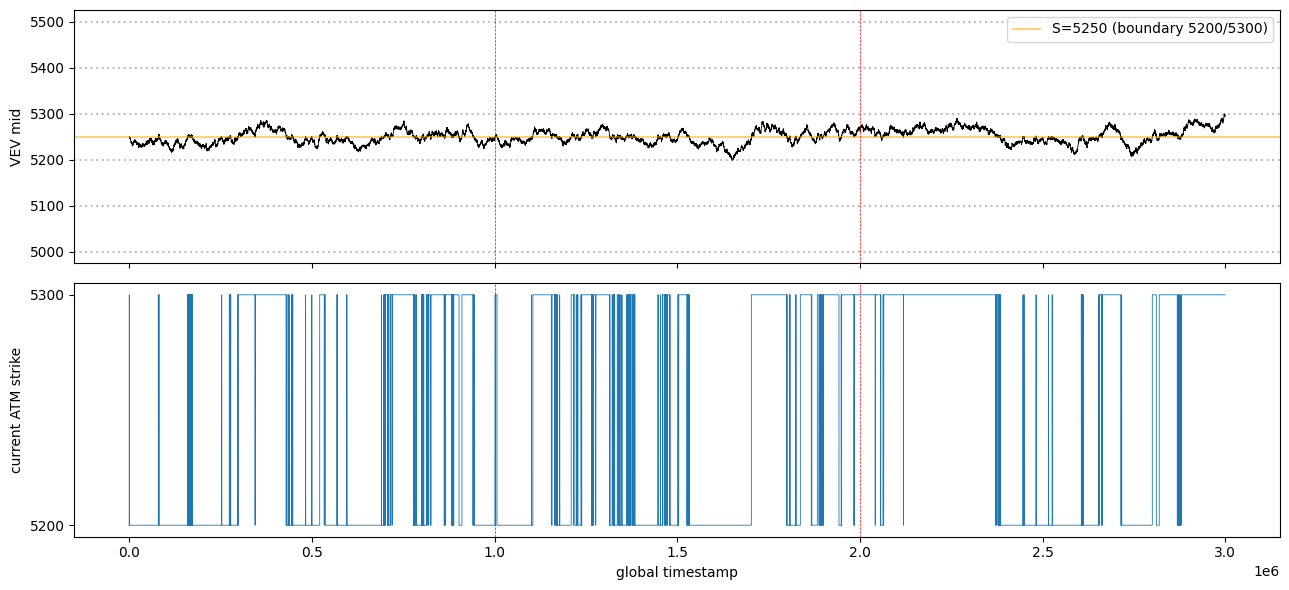

In [7]:
strike_arr = np.array(STRIKE_LIST)
atm_idx = np.argmin(np.abs(strike_arr[None, :] - S[:, None]), axis=1)
atm_strike = strike_arr[atm_idx]
mids["atm_strike"] = atm_strike

switches = (np.diff(atm_strike) != 0).sum()
atm_counts = pd.Series(atm_strike).value_counts().sort_index()
print(f"ATM strike switches: {switches} / {len(atm_strike)} ticks ({100*switches/len(atm_strike):.2f}%)")
print(f"\nATM strike distribution (tick count and %):")
print(pd.DataFrame({"ticks": atm_counts, "pct": 100 * atm_counts / atm_counts.sum()}))

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(mids["global_ts"], S, "k-", lw=0.6)
for k in STRIKE_LIST:
    if 5000 <= k <= 5500:
        axes[0].axhline(k, ls=":", color="grey", alpha=0.5)
axes[0].axhline(5250, ls="-", color="orange", alpha=0.5, label="S=5250 (boundary 5200/5300)")
axes[0].set_ylabel("VEV mid")
axes[0].legend(loc="upper right")
for d in [1, 2]:
    axes[0].axvline(d * 1_000_000, color="red", ls="--", lw=0.5)
    axes[1].axvline(d * 1_000_000, color="red", ls="--", lw=0.5)
axes[1].step(mids["global_ts"], atm_strike, where="post", lw=0.6)
axes[1].set_ylabel("current ATM strike")
axes[1].set_xlabel("global timestamp")
axes[1].set_yticks([5200, 5300])
fig.tight_layout()
plt.show()

**Result.** Across all 30 000 ticks, only K=5200 and K=5300 ever play ATM (52% / 48% split). The boundary is at $S=5250$. The ATM strike switches 523 times (1.7% of ticks). Practically: any "trade the ATM strike" rule will rotate between exactly two strikes — there is essentially no need to handle the general case in a trader.

## 6. Strike triage

Classify each strike by:
- *liquidity*: % of ticks with two-sided market
- *ATM-ness*: % of ticks within ±2 strike-rank steps of the current ATM (since strikes are unevenly spaced — 4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500 — we use rank distance rather than price distance)
- *price floor / ceiling pegging*: whether mid is constant at the 0.5 floor or pinned at intrinsic

Decision rule:
- liquid + ATM-ish + has time value → **primary scalp**
- liquid but never near ATM but has some time value → **secondary**
- price-floor pinned (essentially a constant) or pure intrinsic → **drop**

In [8]:
strike_rank = {k: i for i, k in enumerate(STRIKE_LIST)}
atm_rank_per_tick = np.array([strike_rank[k] for k in atm_strike])

records = []
for v in VOUCHERS:
    k = STRIKES[v]
    rank = strike_rank[k]
    dist = np.abs(atm_rank_per_tick - rank)
    sub = prices[prices["product"] == v]
    pct_two_sided = 100 * ((sub["bid_price_1"].notna()) & (sub["ask_price_1"].notna())).mean()

    # Time value diagnostic: median (mid - max(0, S - K)) at TTE = 5d snapshot
    intrinsic = np.maximum(0, S - k)
    extrinsic = sub["mid_price"].to_numpy() - intrinsic
    extrinsic_med = np.median(extrinsic)
    mid_min = sub["mid_price"].min()
    mid_max = sub["mid_price"].max()
    floor_pegged = (mid_max - mid_min) < 1e-9 and mid_min <= 0.5 + 1e-9
    intrinsic_only = extrinsic_med < 0.6  # only price floor's worth of time value

    pct_within_2 = 100 * (dist <= 2).mean()
    is_atm = 100 * (dist == 0).mean()
    liquid = pct_two_sided > 80
    if floor_pegged or intrinsic_only:
        cls = "drop"
    elif liquid and pct_within_2 >= 50:
        cls = "primary_scalp"
    else:
        cls = "secondary"
    records.append({
        "strike": k,
        "pct_two_sided": pct_two_sided,
        "pct_atm": is_atm,
        "pct_within_2_strikes": pct_within_2,
        "extrinsic_med": extrinsic_med,
        "floor_pegged": floor_pegged,
        "class": cls,
    })
triage = pd.DataFrame(records).sort_values("strike").reset_index(drop=True)
triage.to_csv(f"{CACHE_DIR}/n2_triage.csv", index=False)
triage

,strike,pct_two_sided,pct_atm,pct_within_2_strikes,extrinsic_med,floor_pegged,class
0,4000,100.0000,0.0000,0.0000,0.0000,False,drop
1,4500,100.0000,0.0000,0.0000,0.0000,False,drop
2,5000,100.0000,0.0000,51.8000,4.5000,False,primary_scalp
3,5100,100.0000,0.0000,100.0000,16.5000,False,primary_scalp
4,5200,100.0000,51.8000,100.0000,45.5000,False,primary_scalp
5,5300,100.0000,48.2000,100.0000,47.0000,False,primary_scalp
6,5400,100.0000,0.0000,100.0000,16.5000,False,primary_scalp
7,5500,100.0000,0.0000,48.2000,6.5000,False,secondary
8,6000,100.0000,0.0000,0.0000,0.5000,True,drop
9,6500,100.0000,0.0000,0.0000,0.5000,True,drop


**Triage outcome.**
- **drop**: K=4000, 4500, 6000, 6500. The first two are intrinsic-only (median extrinsic ≈ 0, mid tracks $S - K$), the last two are floor-pegged at 0.5. Neither has tradeable optionality.
- **primary_scalp**: K=5100, 5200, 5300, 5400. All within 2 strike-rank steps of the current ATM 100% of the time, all with substantial extrinsic value.
- **secondary**: K=5000 (51.8% within 2) and K=5500 (48.2% within 2). 5000 has only ~3-4 of extrinsic; 5500 has ~6. Tradeable with thin edge but should not be the main book.

Final tradeable universe: 4 primary (5100/5200/5300/5400) + 2 secondary (5000/5500) = **6 active strikes** out of 10.

## 7. Hedge feasibility

Compute Black-Scholes call delta and vega per strike under a flat-IV assumption ($\sigma = 0.15$, the writeup's reference value) at the typical underlying $S_t \approx 5250$. We do this at each TTE the round will see (8d → 3d) so the trader can plan delta exposure across rounds. Detailed deltas using the fitted smile come from N3 / N4.

Black-Scholes (r=0, no divs):
$$d_1 = \frac{\log(S/K) + 0.5\sigma^2 T}{\sigma\sqrt{T}}, \quad \Delta = N(d_1), \quad \nu = S\,\phi(d_1)\sqrt{T}$$

In [9]:
def bs_d1(S, K, T, sigma):
    return (np.log(S / K) + 0.5 * sigma ** 2 * T) / (sigma * np.sqrt(T))

def bs_delta(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return float(S > K)
    return float(norm.cdf(bs_d1(S, K, T, sigma)))

def bs_vega(S, K, T, sigma):
    if T <= 0 or sigma <= 0:
        return 0.0
    return float(S * norm.pdf(bs_d1(S, K, T, sigma)) * np.sqrt(T))

S_typ = float(np.median(S))
sigma_flat = 0.15
rows = []
for tte_d in [8, 7, 6, 5, 4, 3]:
    T = tte_d / DAYS_PER_YEAR
    for v in VOUCHERS:
        K = STRIKES[v]
        rows.append({
            "tte_d": tte_d, "strike": K,
            "delta": bs_delta(S_typ, K, T, sigma_flat),
            "vega": bs_vega(S_typ, K, T, sigma_flat),
        })
hedge_df = pd.DataFrame(rows)
print(f"S_typ = {S_typ:.1f}, sigma_flat = {sigma_flat}")
print("\nDeltas / vegas at TTE=5d (R3 sim start):")
tte5 = hedge_df[hedge_df["tte_d"] == 5].sort_values("strike").set_index("strike")
tte5["delta_x_300"] = tte5["delta"] * 300
tte5

S_typ = 5249.5, sigma_flat = 0.15

Deltas / vegas at TTE=5d (R3 sim start):


,tte_d,delta,vega,delta_x_300
strike,,,,
4000,5,1.0000,0.0000,300.0000
4500,5,1.0000,0.0000,300.0000
5000,5,0.9973,5.1076,299.1907
5100,5,0.9510,62.3686,285.2956
5200,5,0.7083,210.8891,212.4904
5300,5,0.2958,212.2518,88.7361
5400,5,0.0547,68.0132,16.3979
5500,5,0.0041,7.3885,1.2202
6000,5,0.0000,0.0000,0.0000


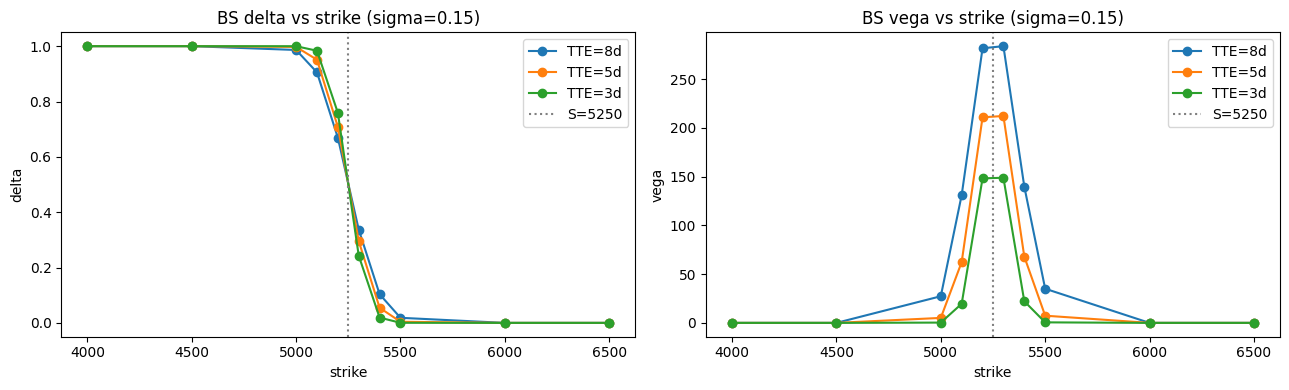

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for tte_d in [8, 5, 3]:
    sub = hedge_df[hedge_df["tte_d"] == tte_d].sort_values("strike")
    axes[0].plot(sub["strike"], sub["delta"], marker="o", label=f"TTE={tte_d}d")
    axes[1].plot(sub["strike"], sub["vega"], marker="o", label=f"TTE={tte_d}d")
for ax in axes:
    ax.axvline(S_typ, color="grey", ls=":", label=f"S={S_typ:.0f}")
    ax.set_xlabel("strike")
    ax.legend()
axes[0].set_ylabel("delta"); axes[0].set_title("BS delta vs strike (sigma=0.15)")
axes[1].set_ylabel("vega"); axes[1].set_title("BS vega vs strike (sigma=0.15)")
fig.tight_layout()
plt.show()

In [11]:
# Position scenarios: long full size on listed strikes, total delta vs VEV cap of 200
scenarios = {
    "long 300 5200 only": [5200],
    "long 300 5300 only": [5300],
    "long 300 5200 + 5300 (both ATM)": [5200, 5300],
    "long 300 primary scalp set (5100..5400)": [5100, 5200, 5300, 5400],
    "long 300 active universe (5000..5500)": [5000, 5100, 5200, 5300, 5400, 5500],
    "long 300 all 10 strikes": list(STRIKES.values()),
    "long 300 deep ITM only (4000+4500)": [4000, 4500],
    "long 300 deep OTM only (6000+6500)": [6000, 6500],
}
tte5_d = tte5["delta"]
rows = []
for name, ks in scenarios.items():
    total_delta = sum(float(tte5_d.loc[k]) * 300 for k in ks)
    rows.append({
        "scenario": name,
        "n_strikes": len(ks),
        "total_delta": total_delta,
        "hedgeable_with_VEV200": abs(total_delta) <= LIMIT_VEV,
        "VEV_needed": abs(total_delta),
    })
scenario_df = pd.DataFrame(rows)
scenario_df

,scenario,n_strikes,total_delta,hedgeable_with_VEV200,VEV_needed
0,long 300 5200 only,1,212.4904,False,212.4904
1,long 300 5300 only,1,88.7361,True,88.7361
2,long 300 5200 + 5300 (both ATM),2,301.2265,False,301.2265
3,long 300 primary scalp set (5100..5400),4,602.9200,False,602.9200
4,long 300 active universe (5000..5500),6,903.3309,False,903.3309
5,long 300 all 10 strikes,10,1503.3309,False,1503.3309
6,long 300 deep ITM only (4000+4500),2,600.0000,False,600.0000
7,long 300 deep OTM only (6000+6500),2,0.0000,True,0.0000


In [12]:
# Per-strike: max long position before that single-strike delta exceeds VEV-200 cap
single_max = []
for k in STRIKE_LIST:
    d = float(tte5_d.loc[k])
    cap = int(LIMIT_VEV / d) if d > 1e-6 else LIMIT_VOUCHER
    cap = min(cap, LIMIT_VOUCHER)
    single_max.append({"strike": k, "delta": d, "max_long_for_full_hedge": cap})
single_max_df = pd.DataFrame(single_max)
single_max_df

,strike,delta,max_long_for_full_hedge
0,4000,1.0000,200
1,4500,1.0000,200
2,5000,0.9973,200
3,5100,0.9510,210
4,5200,0.7083,282
5,5300,0.2958,300
6,5400,0.0547,300
7,5500,0.0041,300
8,6000,0.0000,300
9,6500,0.0000,300


**Hedge-capacity summary.**
- A single full-size long on K=5200 ($\Delta=0.71$) is **already 213 of delta** — over the VEV-200 cap. Per-strike max long for full hedge is 282 contracts (vs the 300 limit).
- Long 300 on both 5200 and 5300 simultaneously is 301 of delta — needs 1.5x VEV capacity, not hedgeable.
- Long 300 across the full primary-scalp set (5100..5400) is 603 of delta — 3x capacity.
- Deep-OTM scenario (long 300 on 6000+6500) is delta-zero (vega is also nil), so trivially hedgeable but also has no PnL potential.
- Deep-ITM scenario (long 300 on 4000+4500) is 600 of delta — these strikes have $\Delta=1$, so they are pure underlying clones with zero scalping edge.

**Practical implication.** The trader **cannot run all primary strikes at full size and stay hedged**. Either:
1. Cap voucher positions per-strike and per-portfolio so net delta $\le 200$ at all times — sacrifices upside, FH approach.
2. Run unhedged net delta — accepts directional VEV risk on top of IV scalping.
3. Concentrate on whichever strike is currently ATM (small set of 1-2 strikes) and rotate as ATM switches.

FH took option 1 + option 3: scalp the ATM strike with a position cap below the hedge ceiling. With our 6-strike active universe and 5200/5300 sharing ATM duty, an envelope like "net portfolio delta within ±200" is feasible if we cap each strike at roughly 100-150 long-equivalent — N4 will compute the exact size limits using the fitted smile.

## 8. Realized trade activity per strike

In [13]:
trade_frames = []
for d in [0, 1, 2]:
    t = pd.read_csv(f"{DATA_DIR}/trades_round_3_day_{d}.csv", sep=";")
    t["day"] = d
    trade_frames.append(t)
trades = pd.concat(trade_frames, ignore_index=True)
print(f"Total trades (all symbols, 3 days): {len(trades)}")
trade_summary = (trades[trades["symbol"].isin(VOUCHERS)]
                 .groupby("symbol")
                 .agg(n_trades=("price", "size"),
                      total_volume=("quantity", "sum"),
                      mean_size=("quantity", "mean"),
                      mean_price=("price", "mean"),
                      min_price=("price", "min"),
                      max_price=("price", "max"))
                 .reset_index())
trade_summary["strike"] = trade_summary["symbol"].map(STRIKES)
trade_summary = trade_summary.sort_values("strike").reset_index(drop=True)
trade_summary.to_csv(f"{CACHE_DIR}/n2_trade_summary.csv", index=False)
trade_summary

Total trades (all symbols, 3 days): 4048


,symbol,n_trades,total_volume,mean_size,mean_price,min_price,max_price,strike
0,VEV_4000,464,940,2.0259,1249.8147,1196.0000,1307.0000,4000
1,VEV_4500,1,1,1.0000,733.0000,733.0000,733.0000,4500
2,VEV_5000,1,1,1.0000,238.0000,238.0000,238.0000,5000
3,VEV_5100,1,1,1.0000,152.0000,152.0000,152.0000,5100
4,VEV_5200,18,63,3.5000,85.2778,74.0000,98.0000,5200
5,VEV_5300,121,420,3.4711,44.1570,28.0000,58.0000,5300
6,VEV_5400,225,787,3.4978,14.8844,7.0000,22.0000,5400
7,VEV_5500,267,937,3.5094,5.9513,2.0000,10.0000,5500
8,VEV_6000,284,1002,3.5282,0.0000,0.0000,0.0000,6000
9,VEV_6500,284,1002,3.5282,0.0000,0.0000,0.0000,6500


**Note.** Trade counts here are **observed third-party trades only** (anonymized buyer/seller fields are blank in early rounds), not our own potential fills. The pattern is that the deep-OTM strikes 6000/6500 have the most trades (284 each) but at price 0.0 — those are dust trades on the floor. K=4000 has 464 trades at mean price ~1250 (intrinsic) — large notional but no optionality. The actually-tradeable strikes (5200..5500) each see between 18 and 267 trades over 3 days (1-90/day). Liquidity is thin in absolute terms but the order book is always two-sided with depth (per cell 2), so we should be able to lift/hit quotes when scalping signals fire.

## 9. Distance-from-spot histogram per strike

Per strike, distribution of $K - S_t$ across all 30 000 ticks. Confirms which strikes are persistently OTM, persistently ITM, or straddle the money.

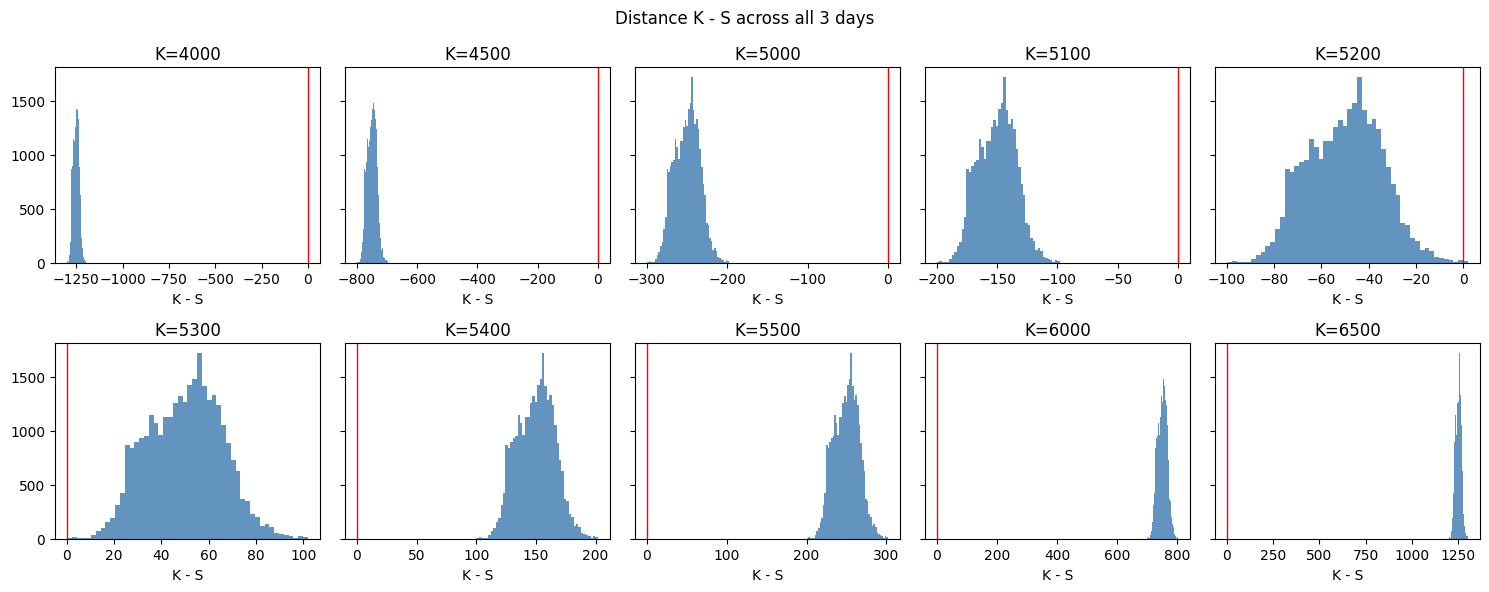

,strike,med_K_minus_S,p25,p75,pct_OTM_for_call,pct_ITM_for_call
0,4000,-1249.5000,-1262.5000,-1238.5000,0.0000,100.0000
1,4500,-749.5000,-762.5000,-738.5000,0.0000,100.0000
2,5000,-249.5000,-262.5000,-238.5000,0.0000,100.0000
3,5100,-149.5000,-162.5000,-138.5000,0.0000,100.0000
4,5200,-49.5000,-62.5000,-38.5000,0.0267,99.9567
5,5300,50.5000,37.5000,61.5000,99.9967,0.0000
6,5400,150.5000,137.5000,161.5000,100.0000,0.0000
7,5500,250.5000,237.5000,261.5000,100.0000,0.0000
8,6000,750.5000,737.5000,761.5000,100.0000,0.0000
9,6500,1250.5000,1237.5000,1261.5000,100.0000,0.0000


In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharey=True)
for ax, v in zip(axes.flatten(), VOUCHERS):
    K = STRIKES[v]
    dists = K - S
    ax.hist(dists, bins=50, color="steelblue", alpha=0.85)
    ax.axvline(0, color="red", lw=1)
    ax.set_title(f"K={K}")
    ax.set_xlabel("K - S")
fig.suptitle("Distance K - S across all 3 days")
fig.tight_layout()
plt.show()

rows = []
for v in VOUCHERS:
    K = STRIKES[v]
    dists = K - S
    rows.append({
        "strike": K,
        "med_K_minus_S": np.median(dists),
        "p25": np.percentile(dists, 25),
        "p75": np.percentile(dists, 75),
        "pct_OTM_for_call": 100 * (dists > 0).mean(),  # K > S => call is OTM
        "pct_ITM_for_call": 100 * (dists < 0).mean(),  # K < S => call is ITM
    })
pd.DataFrame(rows)

**Result.** Only K=5200 straddles the money (99.96% ITM, 0.03% OTM, 0.01% ATM-exact). K=5300 is essentially always OTM (99.997%). All other strikes are 100% on one side of $S$ throughout the 3-day sample. The smile fit in N3 will need to handle the practical reality that 8 of 10 strikes never cross the money in the historical sample.

## Findings & open questions

1. **Two-sidedness is universal.** All 10 strikes show 100% two-sided market on every tick across all 3 days. Liquidity is not a discriminator; *time-value content* is.
2. **VEV trades a 102-point band [5198, 5300]** — under 2% of price. Median 5249.5 sits exactly at the 5200/5300 strike midpoint. Only those two strikes ever play ATM.
3. **ATM rotation is rare**: 523 switches over 30 000 ticks (1.7%). A trader can treat "the ATM strike" as a 2-state variable (5200 vs 5300) flipped at $S = 5250$.
4. **Drop set: K = 4000, 4500, 6000, 6500.** 4000/4500 are pure intrinsic (median extrinsic ≈ 0, $\Delta = 1$); 6000/6500 are pinned at the 0.5 price floor across all 30 000 ticks. No optionality content, no scalping edge possible.
5. **Active universe (6 strikes): primary 5100/5200/5300/5400, secondary 5000/5500.** Spreads are 1-5 ticks, top depth 30+ contracts, real extrinsic value.
6. **Wall mid disagrees with best-mid in 5-50% of ticks but only by ≤ 0.5 in p95.** The wall_mid feature is worth keeping in trader v1 as an FH-baseline replication, but it's a tweak not a structural source of edge.
7. **Hedge cap binds early.** A single full-size long on K=5200 ($\Delta=0.71$) at TTE=5d puts net delta at 213 — already over the VEV-200 cap. Per-strike max for full hedge: ~282 on 5200, ~300 on the OTM strikes (where $\Delta < 0.7$).
8. **Cannot simultaneously run all primary strikes at full size** — long 300 on 5100/5200/5300/5400 is 603 of delta. The trader must either cap voucher sizing, concentrate on the ATM strike, or accept directional underlying exposure.
9. **Realized trade volume on tradeable strikes is 1-90 per day** — thin, but books are always quoted, so signal-driven entries are feasible by hitting/lifting the book.
10. **Open question for N3 / N4**: whether two-strike concentration (always trading whichever is current ATM with rotation at $S = 5250$) gives more or less PnL than spreading across the 4 primary strikes. The hedge math says concentration is strictly more capital-efficient; the smile-fit residual analysis (N3) needs to confirm the per-strike scalping edge is large enough at 5100/5400 to justify the diluted hedge capacity.

**Answer to N2 success criterion.** *Which strikes do we trade, in what priority order, and how big can our voucher book be while staying hedgeable?*

Trade the 4-strike active set 5100 / 5200 / 5300 / 5400, with the current ATM (5200 below $S=5250$, 5300 above) as the primary scalp target and the adjacent strikes as secondary. Drop 4000, 4500, 6000, 6500 entirely. K=5000 and 5500 are optional thin scalps. Voucher book size is constrained by **net portfolio delta ≤ 200**, which at TTE=5d means roughly 280 contracts max if concentrated on a single near-ATM strike, or ~100-150 per strike if spread across the primary set. The trader must compute net delta each tick and clamp before sending orders. Exact per-strike caps using the fitted smile fall to N4.